In [1]:
import pandas as pd
import numpy as np
import sys
import os
import re

sys.path.append(os.path.abspath(".."))
from src.data_processing import BaseDataProcessor

## Data Extraction

In [2]:
src_file = r'..\data\interim\ultra_marathon_races_cleaned.csv'

In [3]:
um_races = BaseDataProcessor(src_file)
um_races.data.sample(5)

2026-05-31 19:55:27 - INFO - Data loaded successfully from ..\data\interim\ultra_marathon_races_cleaned.csv


,year,event_date_str,event_name,event_distance,event_number_of_finishers,athlete_finish_time_str,athlete_club,athlete_country,birth_year,gender,age_category,athlete_average_speed,athlete_id
5299378,2012,20.05.2012,Ohlone 50K Wilderness Run (USA),50km,219,8:57:08 h,NaN,USA,1959.0,M,M50,5.585,25936
2950070,2021,11.-12.09.2021,Trail Côte d'Opale - Challenge 75km (FRA),75km/2Etappen,80,7:37:04 h,NaN,FRA,1973.0,M,M45,9.845,512090
1573255,2017,09.09.2017,Südthüringentrail 65 km (GER),65km,118,9:57:50 h,ESV Lok Döbeln,GER,1961.0,M,M55,6.524,280282
875380,2016,11.06.2016,Esclapa l'Oeil Trail (FRA),62km,127,9:35:15 h,Courir en Pays de Grasse,FRA,1967.0,M,M45,6.467,112202
7153633,1988,03.-04.06.1988,100 km Lauf Biel (SUI),100km,2625,11:53:00 h,*Altdorf,SUI,1943.0,M,M40,8415.0,1540818


### Columns Inspections

In [4]:
event_cols = ['year', 'event_date_str', 'event_name', 'event_distance',]
athlete_cols = ['athlete_id', 'birth_year', 'gender', 'athlete_club', 'athlete_country',]
fact_cols = ['age_category', 'event_number_of_finishers', 'athlete_finish_time_str', 'athlete_average_speed',]

## Event Data

In [5]:
event_data = um_races.data.groupby(event_cols).size().reset_index(name='num_of_athletes')
event_data.insert(0, 'event_id', range(1, len(event_data) + 1))
um_races.data = pd.merge(um_races.data, event_data, on=event_cols, how='left')
um_races.data.drop(columns=event_cols, inplace=True)

In [6]:
event_data.sample(5)

,event_id,year,event_date_str,event_name,event_distance,num_of_athletes
80720,80721,2022,15.-19.10.2022,Big Dog’s Backyard World Championship Belgium ...,101h,15
18143,18144,2008,29.-31.08.2008,48 heures 'Michel Gouin' Drummondville (CAN),48h,12
6620,6621,1995,11.-13.04.1995,Six Day Circuit Race - 48h Split (RSA),48h,15
32861,32862,2014,07.06.2014,Another Dam 50K Run (USA),50km,93
11832,11833,2003,20.09.2003,Cle Elum Ridge 50k (USA),50km,89


<Axes: title={'center': 'Number of Race Events per Year'}, xlabel='Year', ylabel='Number of Events'>

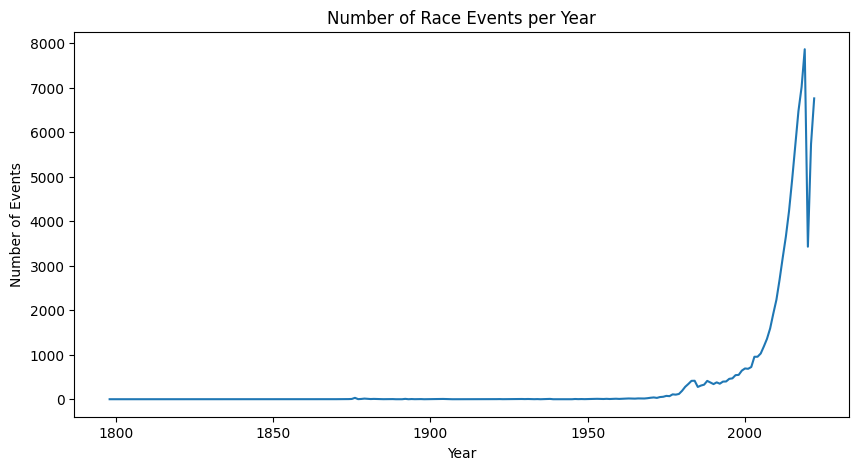

In [7]:
event_data.year.value_counts().sort_index().plot(kind='line', figsize=(10, 5), title='Number of Race Events per Year', ylabel='Number of Events', xlabel='Year')

The trend indicates sustained growth in race events over time, with a gradual rise in the late 20th century and a notably steeper increase after the turn of the century.

### event_date_str

In [8]:
## Check the event_date_str column for parsing issues
event_data.event_date_str.sample(7)

1630                25.10.1981
61384               05.01.2019
55378               09.06.2018
3055                23.06.1985
71343           29.-30.08.2020
41120    31.12.2015-01.01.2016
550                 25.04.1970
Name: event_date_str, dtype: object

In [9]:
event_data.event_date_str.value_counts().head(5)

event_date_str
23.04.2022    134
07.09.2019    123
19.10.2019    116
25.09.2021    115
11.05.2019    114
Name: count, dtype: int64

In [10]:
multi_day_event_check = event_data.event_date_str.str.contains('-')
print(f"Records of one day events: {len(event_data[~multi_day_event_check]):,}")
print(f"Records of multi day events: {len(event_data[multi_day_event_check]):,}")
event_data[multi_day_event_check].event_date_str.value_counts().head(5)

Records of one day events: 58,570
Records of multi day events: 25,554


event_date_str
04.-05.06.2022    58
12.-13.10.2019    53
07.-08.10.2017    51
16.-17.10.2021    49
18.-19.06.2016    49
Name: count, dtype: int64

The `event_date_str` column contains event dates. Most events are single-day occurrences, while multi-day events are represented as a start and end date concatenated with a hyphen (`-`).

This suggests extracting separate `start_date` and `end_date` columns and converting them into proper date format for better consistency and analysis.

In [11]:
def extract_event_dates(date_str):
    if '-' in date_str:
        start_date, end_date = date_str.split('-')
        if len(start_date) == 3:  # Only day is provided in the start date
            start_date = f"{start_date[:2]}.{'.'.join(end_date.split('.')[1:])}"
        elif len(start_date) == 6:  # Only year is missing in the start date
            start_date = f"{start_date[:5]}.{end_date.split('.')[-1]}"
        elif len(start_date) == 10:  # Only year is missing in the start date
            start_date = start_date
        return pd.Series([start_date, end_date])
    else:
        return pd.Series([date_str, date_str])
    

event_data[['event_start_date', 'event_end_date']] = event_data['event_date_str'].apply(extract_event_dates)
event_data.event_start_date = pd.to_datetime(event_data.event_start_date, format='%d.%m.%Y', errors='coerce')
event_data.event_end_date = pd.to_datetime(event_data.event_end_date, format='%d.%m.%Y', errors='coerce')

In [13]:
invalid_event_dates = event_data.event_start_date.isna() | event_data.event_end_date.isna()
print(f"Number of records with invalid event dates: {len(invalid_event_dates):,}")
event_data[invalid_event_dates].sample(5)

Number of records with invalid event dates: 84,124


,event_id,year,event_date_str,event_name,event_distance,num_of_athletes,event_start_date,event_end_date
1218,1219,1980,00.00.1980,Supermaraton Zagreb-Cazma (CRO),61.3km,1,NaT,NaT
3140,3141,1986,00.00.1986,Supermaraton Zagreb-Cazma (CRO),61.3km,2,NaT,NaT
7365,7366,1997,00.00.1997,Szombathely 12 hours running Race - Tudor Bt. ...,12h,5,NaT,NaT
31962,31963,2014,00.00.2014,En courant sur les chemins de Compostelle: Esp...,47km,13,NaT,NaT
813,814,1976,00.00.1976,Supermaraton Zagreb-Cazma (CRO),61.3km,1,NaT,NaT


In [14]:
def fetch_event_duration(start_date, end_date, date_str):
    if pd.isna(start_date) or pd.isna(end_date):
        if '00.00.' == date_str[:6]:
            return date_str[6:]
        elif '00.' == date_str[:3]:
            return pd.to_datetime(date_str[3:], format='%m.%Y', errors='coerce').strftime('%B %Y')
        return 'Unknown'
    elif start_date == end_date:
        return 'One-day'
    else:
        return f'{(end_date-start_date).days + 1} days'

In [15]:
event_data['event_duration'] = event_data.apply(lambda row: fetch_event_duration(row['event_start_date'], row['event_end_date'], row['event_date_str']), axis=1)
event_data.event_duration = event_data.event_duration.astype('string')

In [16]:
event_data[event_data.event_name.str.lower().str.contains('day')].event_name.value_counts().sample(5)

event_name
Dartmoor In A Day Ultra (GBR)                    3
San Francisco One Day, 24h (USA)                 6
Across the Years, 6 days - 100mi Split (USA)     1
Copenhagen 6-Day Challenge - 48h Split (DEN)     1
Mother's Day six hour race (USA)                19
Name: count, dtype: int64

Well some events are anual or monthly thus will keep event_date_str so far

In [20]:
event_data[event_data.event_name=='San Francisco One Day, 24h (USA)']

,event_id,year,event_date_str,event_name,event_distance,num_of_athletes,event_start_date,event_end_date,event_duration
15214,15215,2006,28.-29.10.2006,"San Francisco One Day, 24h (USA)",24h,31,2006-10-28,2006-10-29,2 days
16189,16190,2007,20.-21.10.2007,"San Francisco One Day, 24h (USA)",24h,48,2007-10-20,2007-10-21,2 days
17941,17942,2008,25.-26.10.2008,"San Francisco One Day, 24h (USA)",24h,67,2008-10-25,2008-10-26,2 days
19713,19714,2009,24.-25.10.2009,"San Francisco One Day, 24h (USA)",24h,63,2009-10-24,2009-10-25,2 days
21771,21772,2010,23.-24.10.2010,"San Francisco One Day, 24h (USA)",24h,48,2010-10-23,2010-10-24,2 days
53325,53326,2018,01.-02.06.2018,"San Francisco One Day, 24h (USA)",24h,46,2018-06-01,2018-06-02,2 days


### event_name

In [21]:
event_data.event_name.value_counts().sample(7)

event_name
A Stroll in The Park 12-Hour Endurance Run (USA)       7
Devil Dog Ultra 100 Mile Race (USA)                    6
IAU 100km EC Belves (100 km du Périgord Noir) (FRA)    1
Glasshouse Mountains 50km Trail Race (AUS)             5
6-Stunden-Lauf Herne - offner Lauf (GER)               1
Chester Ultra 50 Miles (GBR)                           6
Ultrabericus Cento (ITA)                               1
Name: count, dtype: int64

In [22]:
event_data['event_country'] = event_data.event_name.str.split('(').str[-1].str.replace(')', '', regex=False).str.strip()
event_data['event_name'] = event_data.event_name.str.split('(').str[0].str.strip()
event_data.event_country.value_counts().head(10)

event_country
USA    27459
FRA     7399
GER     4572
GBR     4498
AUS     3621
ITA     3239
JPN     2667
TPE     2353
CAN     2170
CHN     1692
Name: count, dtype: int64

In [23]:
event_data.sample(5)

,event_id,year,event_date_str,event_name,event_distance,num_of_athletes,event_start_date,event_end_date,event_duration,event_country
41015,41016,2015,31.01.2015,Ordnance 100K,100km,40,2015-01-31,2015-01-31,One-day,USA
65640,65641,2019,21.-22.12.2019,Chongqing International Trail Running - 60km,60.9km,77,2019-12-21,2019-12-22,2 days,CHN
29461,29462,2013,10.08.2013,Ultra Trail Vall d'Aran,66km,79,2013-08-10,2013-08-10,One-day,ESP
60702,60703,2019,02.03.2019,12h de Capitany,12h,54,2019-03-02,2019-03-02,One-day,FRA
68497,68498,2020,03.10.2020,Akamas Blossom Trail,60km,35,2020-10-03,2020-10-03,One-day,CYP


### event_distance

In [24]:
def parse_distance(d):
    """Extract numeric km distance from strings like '50km', '100mi', '6h'."""
    d = str(d).strip().lower()
    # Timed events (e.g. 6h, 24h) → flag as timed
    if re.search(r'\dh|d$', d) or 'hour' in d:
        return np.nan   # handled separately
    km_match = re.search(r'([\d.]+)\s*(km|k)\b', d, re.IGNORECASE)
    mi_match = re.search(r'([\d.]+)\s*(mi|m|mile|miles)\b', d, re.IGNORECASE)
    if km_match:
        return float(km_match.group(1))
    if mi_match:
        return round(float(mi_match.group(1)) * 1.60934, 2)
    try:
        return float(d)
    except:
        return np.nan
    
def parse_timed_event_duration(d):
    """Convert timed event durations like '6h', '24h' to hours."""
    d = str(d).strip().lower()
    if 'etappe' in d:
        return np.nan
    # match = re.search(r'(\d+)(?::(\d+))?\s*h', d)
    match = re.search(r'(\d+)(?::(\d+))?\s*h?', d)
    if match:
        hours = int(match.group(1))
        minutes = int(match.group(2) or 0)
        return hours*60 + minutes 
        # return [match, hours, minutes]
    day_match = re.search(r'(\d+)\s*d', d)
    if day_match:
        return int(day_match.group(1)) * 24 * 60
        # return day_match
    return np.nan

event_data['distance_km'] = event_data.event_distance.apply(parse_distance)
event_data['timed_event_duration_min'] = event_data.event_distance.apply(parse_timed_event_duration)

In [25]:
event_data['event_type'] = np.where(event_data.timed_event_duration_min.notna(), 'Timed',
                                    np.where(event_data.distance_km.notna() & event_data.event_name.str.lower().str.contains('etappe'), 'Multi-Stage', 'Distance'))

In [26]:
event_data.event_type.value_counts()

event_type
Timed          82535
Distance        1559
Multi-Stage       30
Name: count, dtype: int64

In [34]:
event_columns = [
    'event_id', 'event_name', 'event_country', 'year', 'event_start_date', 'event_end_date', 'event_distance', 'distance_km', 'timed_event_duration_min', 'event_type',
    'event_date_str', 'event_duration', 'num_of_athletes',

]
event_data = event_data[event_columns]

In [35]:
event_data.sample(10)

,event_id,event_name,event_country,year,event_start_date,event_end_date,event_distance,distance_km,timed_event_duration_min,event_type,event_date_str,event_duration,num_of_athletes
37625,37626,Avalon Benefit 50-Mile Run,USA,2015,2015-01-10,2015-01-10,50mi,80.47,3000.0,Timed,10.01.2015,One-day,209
68138,68139,La Chute du Diable 50 Km,CAN,2019,2019-08-31,2019-08-31,50km,50.00,3000.0,Timed,31.08.2019,One-day,95
44975,44976,Trail delle Valli Etrusche,ITA,2016,2016-03-20,2016-03-20,50km,50.00,3000.0,Timed,20.03.2016,One-day,151
17601,17602,Les 12 heures de Bures-sur-Yvette,FRA,2008,2008-05-18,2008-05-18,12h,NaN,720.0,Timed,18.05.2008,One-day,63
80676,80677,Palisades Ultra Trail Series,USA,2022,2022-07-15,2022-07-16,100mi,160.93,6000.0,Timed,15.-16.07.2022,2 days,5
31411,31412,Dusk 'til Dawn 50 Mile Ultra,GBR,2013,2013-10-26,2013-10-26,50mi,80.47,3000.0,Timed,26.10.2013,One-day,70
66495,66496,Moebius Green Monster Trail 50K,USA,2019,2019-08-24,2019-08-24,50km,50.00,3000.0,Timed,24.08.2019,One-day,50
52973,52974,Trail Le Saint Guiral 60 km,FRA,2017,2017-04-29,2017-04-29,60km,60.00,3600.0,Timed,29.04.2017,One-day,285
22491,22492,"Self-Transcendence 12 Hour Track Race, Auckland",NZL,2011,2011-10-01,2011-10-01,12h,NaN,720.0,Timed,01.10.2011,One-day,10
74045,74046,Homer Epic 100k Race,USA,2021,2021-03-13,2021-03-14,100km,100.00,6000.0,Timed,13.-14.03.2021,2 days,5


### others

In [ ]:
def get_event_type(d):
    d = str(d).strip().lower()
    if re.search(r'\dh|hour|d|day', d):
        return 'Timed'
    if re.search(r'/', d):
        return 'Multi-Stage'
    return 'Distance'

In [ ]:
event_data['event_type']  = event_data.event_distance.apply(get_event_type)

In [ ]:
event_data.event_type.value_counts()

In [ ]:
event_data[event_data.event_type=='Multi-Stage'].event_distance.value_counts()#.head(10)

In [ ]:
event_data['distance_km'] = event_data.event_distance.apply(parse_distance)

In [ ]:
event_data[(event_data.distance_km.isna()) & (event_data.timed_event_duration_min.isna())]#.event_distance.value_counts().head(10)

In [ ]:
event_data[event_data.event_type=='Multi-Stage']